<a href="https://colab.research.google.com/github/Avi0095/Deep-Learning-Project/blob/main/Alzhimer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()  # select dataset.zip

Saving Alzheimer (Preprocessed Data).zip to Alzheimer (Preprocessed Data) (2).zip


In [ ]:
import zipfile
import io
import os

# Define the target extraction directory
extract_dir = "/content/dataset/"

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

for fn in uploaded.keys():
    print(f"Extracting {fn} to {extract_dir}")
    with zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

Extracting Alzheimer (Preprocessed Data) (2).zip to /content/dataset/


In [ ]:
import os
if os.path.exists("/content/dataset/"):
    print(os.listdir("/content/dataset/"))
else:
    print("Directory /content/dataset/ does not exist. Please ensure the dataset is unzipped correctly.")

['Alzheimer (Preprocessed Data)']


import the library

In [ ]:
!pip install tf-explain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tf_explain.core.grad_cam import GradCAM

dataset setup

Detected Classes: ['Moderate_Demented', 'Very_Mild_Demented', 'Non_Demented', 'Mild_Demented']


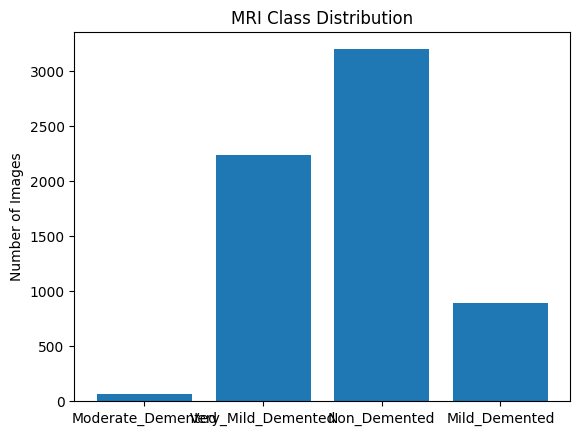

In [ ]:
dataset_dir = "/content/dataset/Alzheimer (Preprocessed Data)"  # e.g., 'dataset/'

# Check classes
classes = [c for c in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, c))]
print("Detected Classes:", classes)

# Visualize class distribution
class_counts = {c: len(os.listdir(os.path.join(dataset_dir, c))) for c in classes}
plt.bar(class_counts.keys(), class_counts.values())
plt.title("MRI Class Distribution")
plt.ylabel("Number of Images")
plt.show()

One hot encoding+train/test split

In [ ]:
img_size = (128,128)
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255,
                             validation_split=0.2,
                             rotation_range=15,
                             zoom_range=0.1,
                             horizontal_flip=True)

train_gen = datagen.flow_from_directory(dataset_dir,
                                        target_size=img_size,
                                        batch_size=batch_size,
                                        class_mode='categorical',
                                        subset='training')

val_gen = datagen.flow_from_directory(dataset_dir,
                                      target_size=img_size,
                                      batch_size=batch_size,
                                      class_mode='categorical',
                                      subset='validation')

classes_dict = train_gen.class_indices
classes_list = list(classes_dict.keys())
print("Class Mapping:", classes_dict)

Found 5121 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.
Class Mapping: {'Mild_Demented': 0, 'Moderate_Demented': 1, 'Non_Demented': 2, 'Very_Mild_Demented': 3}


feature Extraction+Model(hybrid CNN + transfer learning)

In [ ]:
base_model = tf.keras.applications.ResNet50(weights='imagenet',
                                            include_top=False,
                                            input_shape=(img_size[0], img_size[1], 3))
base_model.trainable = False  # Freeze base layers for fast inference

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(classes_list), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

DenseNet/EfficientNet + Attention

In [ ]:
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Multiply, Activation, Lambda
import tensorflow.keras.backend as K
import tensorflow as tf # Import tensorflow explicitly
from tensorflow.keras.layers import Conv2D # Import Conv2D

# --- Base Model ---
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  # freeze for fast training

x = base_model.output
x = GlobalAveragePooling2D()(x)

# --- Attention Layer ---
def attention_block(x_tensor):
    # simple channel attention
    avg_pool = Lambda(lambda t: tf.reduce_mean(t, axis=[1], keepdims=True))(x_tensor)
    max_pool = Lambda(lambda t: tf.reduce_max(t, axis=[1], keepdims=True))(x_tensor)
    concat = tf.keras.layers.Concatenate(axis=-1)([avg_pool, max_pool])
    # Name the Conv2D layer explicitly for Grad-CAM targeting
    attention = Conv2D(filters=K.int_shape(x_tensor)[-1], kernel_size=1, padding='same', activation='sigmoid', name='grad_cam_target_conv2d')(concat)
    return Multiply()([x_tensor, attention])

# Adapt shape for attention block (GlobalAveragePooling2D output is 2D, needs to be 4D for Conv2D)
x = Lambda(lambda t: tf.expand_dims(tf.expand_dims(t, 1), 1))(x)

x = attention_block(x) # Call the attention block with the adapted tensor
x = Lambda(lambda t: tf.squeeze(t, [1,2]))(x) # Squeeze back to 2D after attention
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(classes_list), activation='softmax')(x) # Corrected num_classes to len(classes_list)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_10   │ (None, 134, 134,  │          0 │ input_layer_9[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d_1… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_11   │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 9,399,108 (35.85 MB)

 Trainable params: 2,361,604 (9.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Train model

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_mri_model.h5', monitor='val_accuracy', save_best_only=True)

history = model.fit(train_gen,
                    validation_data=val_gen,
                    epochs=25,
                    callbacks=[early_stop, checkpoint])

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 52/641 ━━━━━━━━━━━━━━━━━━━━ 4:30 460ms/step - accuracy: 0.4399 - loss: 1.6195

KeyboardInterrupt: 

Grad-Cam Explainable AI

In [ ]:
val_images, val_labels = next(val_gen)
sample_image = val_images[0:1]  # single image
sample_label = np.argmax(val_labels[0])

explainer = GradCAM()
# Explicitly specify the layer for Grad-CAM, which is the Conv2D layer within the attention block
grid = explainer.explain((sample_image, None), model, class_index=sample_label, layer_name='grad_cam_target_conv2d')
explainer.save(grid, ".", "gradcam_output.png")
print("Grad-CAM saved as gradcam_output.png")


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_2303']]
Received: inputs=['Tensor(shape=(1, 128, 128, 3))']
  warnings.warn(msg)


Grad-CAM saved as gradcam_output.png


In [ ]:
def recommend(stage):
    recommendations = {
        "Non_Demented": "Maintain healthy lifestyle. Routine check-up.",
        "Very_Mild_Demented": "Memory exercises, lifestyle improvements, follow-up scan in 6 months.",
        "Mild_Demented": "Cognitive therapy, medical evaluation, regular monitoring.",
        "Moderate_Demented": "Immediate clinical intervention, family support, treatment plan."
    }
    return recommendations.get(stage, "No recommendation")


AI assistent recommendation

In [ ]:
def recommend(stage):
    recommendations = {
        "NonDemented": "Maintain healthy lifestyle. Routine check-up.",
        "VeryMildDemented": "Memory exercises, lifestyle improvements, follow-up scan in 6 months.",
        "MildDemented": "Cognitive therapy, medical evaluation, regular monitoring.",
        "ModerateDemented": "Immediate clinical intervention, family support, treatment plan."
    }
    return recommendations.get(stage, "No recommendation")


Streamlit

In [ ]:
st.title("AI-Based Early Alzheimer’s Detection System")

uploaded_file = st.file_uploader("Upload MRI Image", type=["jpg","png"])
if uploaded_file:
    img = Image.open(uploaded_file).convert('RGB').resize(img_size)
    st.image(img, caption='Uploaded MRI', use_column_width=True)

    img_array = np.expand_dims(np.array(img)/255.0, axis=0)
    model = load_model("best_mri_model.h5")
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    predicted_stage = classes_list[class_idx]

    st.success(f"Predicted Stage: {predicted_stage}")

    # Grad-CAM highlight
    explainer = GradCAM()
    grid = explainer.explain((img_array, None), model, class_index=class_idx)
    explainer.save(grid, ".", "gradcam_uploaded.png")
    st.image("gradcam_uploaded.png", caption="Grad-CAM Highlighted Regions")

    # AI Recommendation
    st.info(recommend(predicted_stage))